In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["savefig.dpi"] = 300  # Set default dpi to 300 for saving figures

# Price function

In [2]:
def sigmoid(r,s,m,ku,kl):
    return ku - ((ku-kl)/(1+np.exp(-s*(r-m))))

In [3]:
num_rows= 200
ratios= [i/50 for i in range(1,num_rows)]

data_plot=pd.DataFrame({
    'Demand-to-Supply Ratio (M/E)': ratios
}|{i:[sigmoid(r**-1,i,1,0.4,0.08)for r in ratios]for i in np.arange(1,7,step=0.1)})
dfl = pd.melt(data_plot, ['Demand-to-Supply Ratio (M/E)'],var_name='B',value_name="Price in €/kWh")

Text(0.5, 1.0, 'Price Function for Different Values of B')

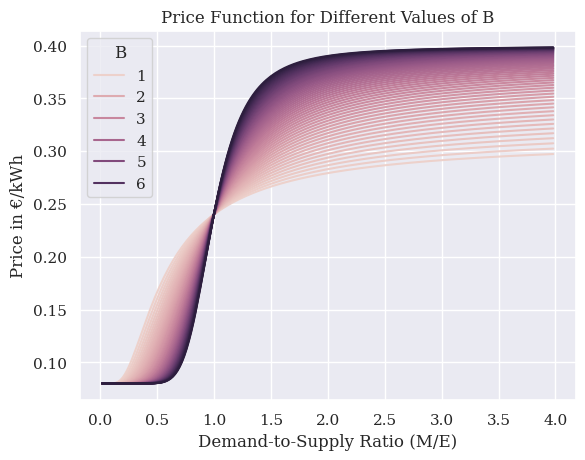

In [4]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
sns.lineplot(data=dfl, x='Demand-to-Supply Ratio (M/E)', y='Price in €/kWh', hue='B').set_title("Price Function for Different Values of B")

In [5]:
num_rows= 400
ratios= [i/100 for i in range(1,num_rows)]
data_plot=pd.DataFrame({
    'Demand-to-Supply Ratio (M/E)': ratios
}|{i:[sigmoid(1/r,10,i,0.4,0.08) for r in ratios]for i in np.arange(0.1,1,step=0.01)})
dfl = pd.melt(data_plot, ['Demand-to-Supply Ratio (M/E)'],var_name=r'$\theta$',value_name="Price in €/kWh")

Text(0.5, 1.0, 'Price Function for Different Values of $\\theta$')

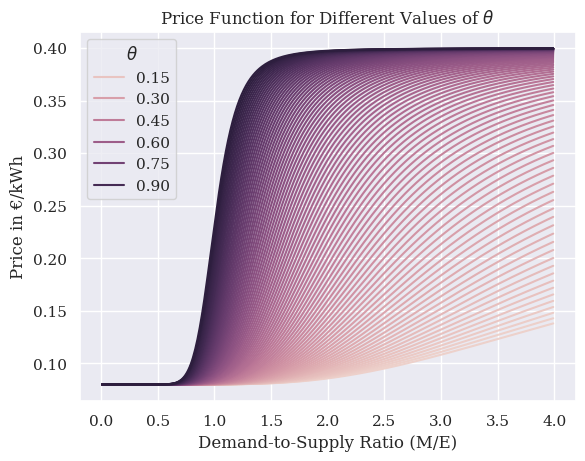

In [6]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
sns.lineplot(data=dfl, x='Demand-to-Supply Ratio (M/E)', y='Price in €/kWh', hue=r'$\theta$').set_title(r"Price Function for Different Values of $\theta$")

# Data prep

In [2]:
###### AMMBA results #########
data30 = pd.read_excel("./simulation_results/AMMBA_result_data_30_pv.xlsx")
data30["clock"]=pd.to_datetime(data30["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
data30=data30.rename(columns={'clock':'time','pv_gen':'Produced Energy','load':"Used Energy"})
agg30 = data30.groupby(by="Time").agg({'Produced Energy':"sum",'Used Energy':"sum","time":"first","surplus":"sum","demand":"sum",'money_in':"sum","energy_in":"sum","price":"mean"})
dfm30 = agg30.melt("time", var_name='Group', value_name='kWh')

data50 = pd.read_excel("./simulation_results/AMMBA_result_data_50_pv.xlsx")
data50["clock"]=pd.to_datetime(data50["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
data50=data50.rename(columns={'clock':'time','pv_gen':'Produced Energy','load':"Used Energy"})
agg50 = data50.groupby(by="Time").agg({'Produced Energy':"sum",'Used Energy':"sum","time":"first","surplus":"sum","demand":"sum",'money_in':"sum","energy_in":"sum","price":"mean"})
dfm50 = agg50.melt("time", var_name='Group', value_name='kWh')

data70 = pd.read_excel("./simulation_results/AMMBA_result_data_70_pv.xlsx")
data70["clock"]=pd.to_datetime(data70["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
data70=data70.rename(columns={'clock':'time','pv_gen':'Produced Energy','load':"Used Energy"})
agg70 = data70.groupby(by="Time").agg({'Produced Energy':"sum",'Used Energy':"sum","time":"first","surplus":"sum","demand":"sum",'money_in':"sum","energy_in":"sum","price":"mean","buy_price":"mean","sell_price":"mean"})
dfm70 = agg70.melt("time", var_name='Group', value_name='kWh')

########## Order Book results #############

data30_OMB = pd.read_excel("./simulation_results/OBM_result_data_30_pv.xlsx")
data30_OMB["clock"]=pd.to_datetime(data30_OMB["clock"],format="%H:%M").dt.strftime('%H:%M')
data30_OMB=data30_OMB.rename(columns={'clock':'time','pv_gen':'Produced Energy','load':"Used Energy"})
agg30_OMB = data30_OMB.groupby(by="Time").agg({'Produced Energy':"sum",'Used Energy':"sum","time":"first","surplus":"sum","demand":"sum",'money_in':"sum","energy_in":"sum","price":"mean"})
dfm30_OMB = agg30_OMB.melt("time", var_name='Group', value_name='kWh')

data50_OMB = pd.read_excel("./simulation_results/OBM_result_data_50_pv.xlsx")
data50_OMB["clock"]=pd.to_datetime(data50_OMB["clock"],format="%H:%M").dt.strftime('%H:%M')
data50_OMB=data50_OMB.rename(columns={'clock':'time','pv_gen':'Produced Energy','load':"Used Energy"})
agg50_OMB = data50_OMB.groupby(by="Time").agg({'Produced Energy':"sum",'Used Energy':"sum","time":"first","surplus":"sum","demand":"sum",'money_in':"sum","energy_in":"sum","price":"mean"})
dfm50_OMB = agg50_OMB.melt("time", var_name='Group', value_name='kWh')

data70_OMB = pd.read_excel("./simulation_results/OBM_result_data_70_pv.xlsx")
data70_OMB["clock"]=pd.to_datetime(data70_OMB["clock"],format="%H:%M").dt.strftime('%H:%M')
data70_OMB=data70_OMB.rename(columns={'clock':'time','pv_gen':'Produced Energy','load':"Used Energy"})
agg70_OMB = data70_OMB.groupby(by="Time").agg({'Produced Energy':"sum",'Used Energy':"sum","time":"first","surplus":"sum","demand":"sum",'money_in':"sum","energy_in":"sum","price":"mean"})

# Data vis

## Total damnd and supply

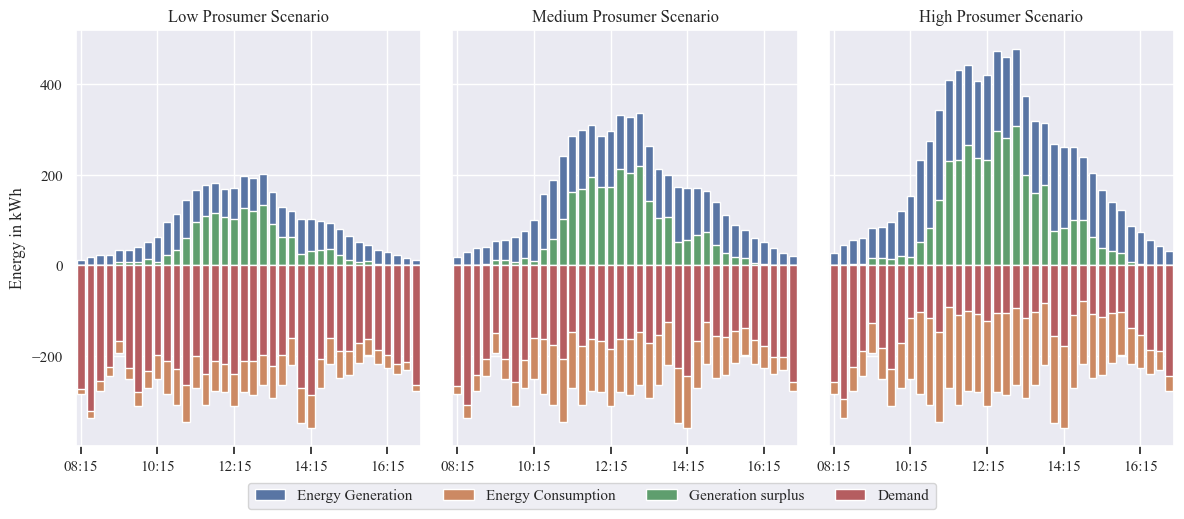

In [58]:
input_data30 = pd.read_excel("./data/input_data_30_pv.xlsx")
input_data50 = pd.read_excel("./data/input_data_50_pv.xlsx")
input_data70 = pd.read_excel("./data/input_data_70_pv.xlsx")
input_data30["clock"]=pd.to_datetime(input_data30["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
agg1 = input_data30.groupby("Time").agg({"demand":"sum","surplus":"sum","clock":"min","pv_gen":"sum","load":"sum"})
agg1["load"] = -agg1["load"]
agg1["demand"] = -agg1["demand"]

input_data50["clock"]=pd.to_datetime(input_data50["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
agg2 = input_data50.groupby("Time").agg({"demand":"sum","surplus":"sum","clock":"min","pv_gen":"sum","load":"sum"})
agg2["load"] = -agg2["load"]
agg2["demand"] = -agg2["demand"]

input_data70["clock"]=pd.to_datetime(input_data70["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
agg3 = input_data70.groupby("Time").agg({"demand":"sum","surplus":"sum","clock":"min","pv_gen":"sum","load":"sum"})
agg3["load"] = -agg3["load"]
agg3["demand"] = -agg3["demand"]

dfm1 = agg1.melt("clock", var_name='Group', value_name='kWh')
dfm2 = agg2.melt("clock", var_name='Group', value_name='kWh')
dfm3 = agg3.melt("clock", var_name='Group', value_name='kWh')

fig, ax = plt.subplots(1, 3, figsize=(12, 5),sharey=True)
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
sns.set_theme(rc={'font.family':'serif', 'font.serif':'Times New Roman'},style="darkgrid")
plot = sns.barplot(data=dfm1, x='clock', y='kWh', hue='Group', ax=ax[0],dodge=False,hue_order=["pv_gen","load","surplus","demand"])
plot.set_title("Low Prosumer Scenario")
sns.barplot(data=dfm2, x='clock', y='kWh', hue='Group', ax=ax[1],dodge=False,hue_order=["pv_gen","load","surplus","demand"],legend=False).set_title("Medium Prosumer Scenario")
sns.barplot(data=dfm3, x='clock', y='kWh', hue='Group', ax=ax[2],dodge=False,hue_order=["pv_gen","load","surplus","demand"],legend=False).set_title("High Prosumer Scenario")
legend_handles, _= plot.get_legend_handles_labels()
fig.legend(loc=8,ncols=4,bbox_to_anchor=(0.5, -0.05),handles=legend_handles, labels=['Energy Generation',"Energy Consumption","Generation surplus","Demand"])
ax[0].set_xticks(np.arange(0, len(agg1), 8))
ax[0].tick_params('x',bottom=True, labelbottom=True)
ax[0].set_ylabel("Energy in kWh")
ax[0].grid(True)
ax[0].legend().set_visible(False)
ax[0].set_xlabel(None)
ax[1].set_xticks(np.arange(0, len(agg1), 8))
ax[1].tick_params('x',bottom=True, labelbottom=True)
ax[1].grid(True)
ax[1].set_xlabel(None)
ax[2].set_xticks(np.arange(0, len(agg1), 8))
ax[2].tick_params('x',bottom=True, labelbottom=True)
ax[2].grid(True)
ax[2].set_xlabel(None)
#plot.set_xticks(np.arange(0, 97, 6))
#plot.set(xlabel ="Time", ylabel = "kWh", title ='Energy Generation and Consumption Over Time',label=False)
plt.tight_layout()
fig= plot.get_figure()
fig.savefig("./Images/Generation and Consumption.png",bbox_inches='tight')

In [60]:
print(agg1["surplus"].sum())
print(agg1["demand"].sum())
print(agg2["surplus"].sum())
print(agg2["demand"].sum())
print(agg3["surplus"].sum())
print(agg3["demand"].sum())

1478.93454253
-7902.257932682
2488.406177316
-6675.247366998999
3527.145462803
-5161.993279371


## Buy Price vis

In [5]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
agg = data.groupby("Time").agg({"surplus":"sum","demand":"sum","buy_price":"mean","sell_price":"mean","time":"min"})
agg["supply_demand_ratio"]=agg["surplus"]/agg["demand"]
dfm2 = agg.melt(id_vars="time",value_vars=["buy_price","sell_price"],value_name="vals",var_name="x")
plot = sns.lineplot(data=dfm2,x="time",y="vals",hue="x")

#ax2 = plt.twinx()
#plot= sns.lineplot(data=agg,x="time",y="supply_demand_ratio",ax=ax2)
plot.set_xticks(np.arange(0, 97, 6))
plot.set(xlabel ="Time", ylabel = "Price per kWh in €", title ='Retail price and FiT for energy throughout the day',label=False)
x = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)
plot.fill_between([36,69],0,1,transform=plot.get_xaxis_transform(),color="green",alpha=0.3,label="Period with energy surplus")
legend_handles, _= plot.get_legend_handles_labels()
plot.legend(legend_handles, ["Retail Price",'FiT',"Period with energy surplus"],loc=2,fontsize="xx-small")
fig= plot.get_figure()
fig.savefig("./Images/buy prices.png")

NameError: name 'data' is not defined

In [9]:
agg["supply_demand_ratio"] = agg["surplus"]/agg["demand"]
agg[agg["surplus"]>0]["supply_demand_ratio"].mean()

np.float64(1.4941448558285344)

# Price Function vis

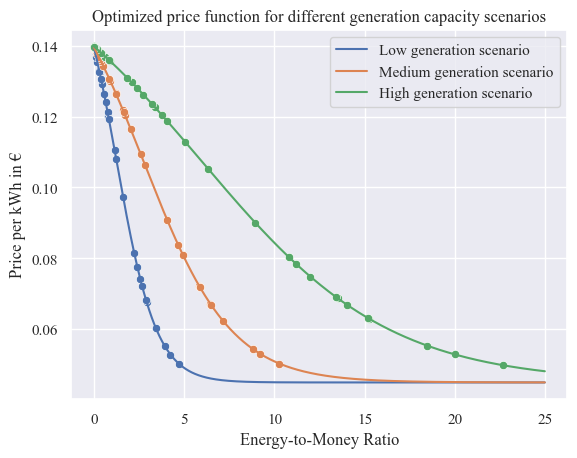

In [6]:
def sigmoid(r,m,s,ku,kl):
    return ku - ((ku-kl)/(1+np.exp(-s*(r-m))))
params_low = (np.float64(1.252280038881754),np.float64(0.9025061693804254))
params_mid= (np.float64(2.7366558386807447),np.float64(0.4127245127514755))
params_high = (np.float64(5.953998393410741),np.float64(0.19187317821232616))
x = np.arange(0,25,step=0.01)
y_low = [sigmoid(i,*params_low,0.17,0.045) for i in x]
y_mid = [sigmoid(i,*params_mid,0.17,0.045) for i in x]
y_high = [sigmoid(i,*params_high,0.17,0.045) for i in x]
r_low = agg30[agg30["energy_in"]>0]["energy_in"]/agg30["money_in"]
p_low = [sigmoid(i,*params_low,0.17,0.045) for i in r_low]
r_mid = agg50[agg50["energy_in"]>0]["energy_in"]/agg50["money_in"]
p_mid = [sigmoid(i,*params_mid,0.17,0.045) for i in r_mid]
r_high = agg70[agg70["energy_in"]>0]["energy_in"]/agg70["money_in"]
p_high = [sigmoid(i,*params_high,0.17,0.045) for i in r_high]
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})

plot = sns.lineplot(x=x,y=y_low,label="Low generation scenario")
sns.lineplot(x=x,y=y_mid,label="Medium generation scenario")
sns.lineplot(x=x,y=y_high,label="High generation scenario")
sns.scatterplot(x=r_low,y=p_low)
sns.scatterplot(x=r_mid,y=p_mid)
plot = sns.scatterplot(x=r_high,y=p_high)
l = plot.set(xlabel ="Energy-to-Money Ratio", ylabel = "Price per kWh in €", title ='Optimized price function for different generation capacity scenarios')
#plot.legend(["Low Generation Capacity","Medium Generation Capacity","High Generation Capacity"])
fig= plot.get_figure()
fig.savefig("./Images/Optimized Price Functions.png")

C:\Users\hmart\AppData\Local\Temp\ipykernel_35532\1435094994.py:74: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(ax=axes[1][0],data=data30_OMB.sort_values("Time",ascending=True)[filter1],x="time",y="price",errorbar="sd")
C:\Users\hmart\AppData\Local\Temp\ipykernel_35532\1435094994.py:85: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(ax=axes[1][1],data=data50_OMB.sort_values("Time",ascending=True)[filter2],x="time",y="price",errorbar="sd")
C:\Users\hmart\AppData\Local\Temp\ipykernel_35532\1435094994.py:91: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(ax=axes[1][2],data=data70_OMB.sort_values("Time",ascending=True)[filter3],x="time",y="price",errorbar="sd")


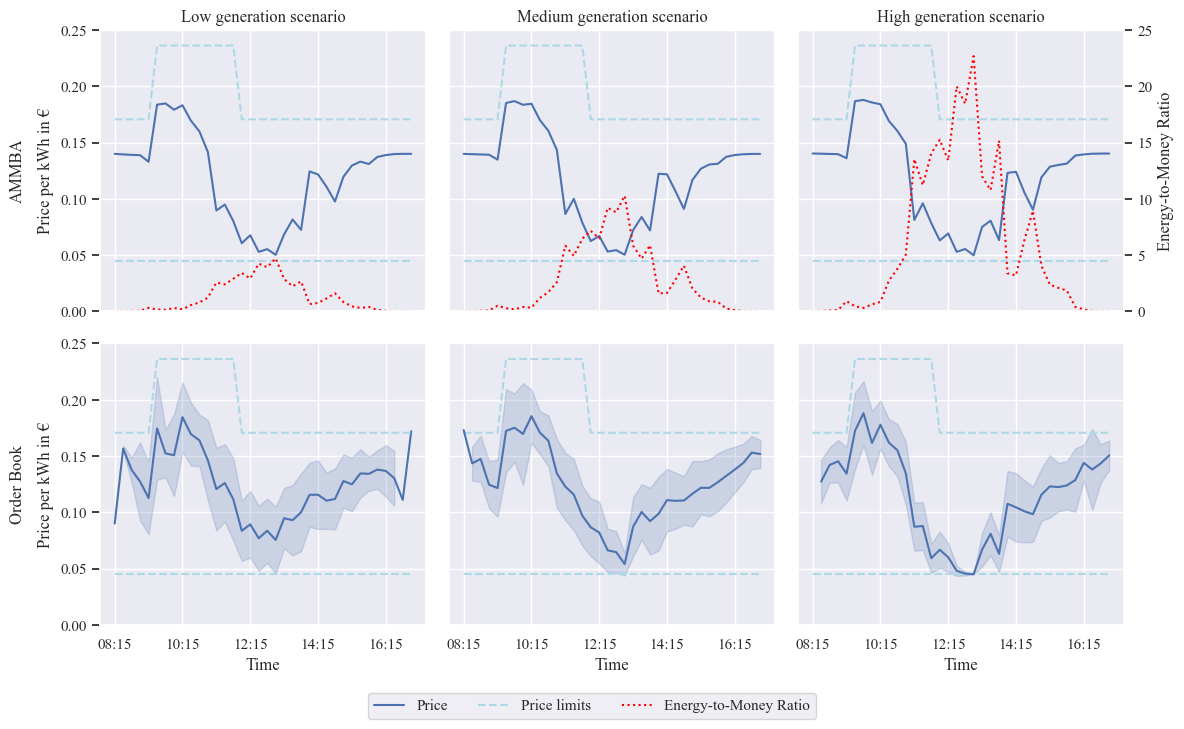

In [7]:
plt.rc('axes', axisbelow=True)
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
prices_low = agg30[agg30["energy_in"]>0]["price"]
times_low = agg30[agg30["energy_in"]>0]["time"]
prices_mid = agg50[agg50["energy_in"]>0]["price"]
times_mid = agg50[agg50["energy_in"]>0]["time"]
prices_high = agg70[agg70["energy_in"]>0]["price"]
times_high = agg70[agg70["energy_in"]>0]["time"]
upper = agg70[agg70["energy_in"]>0]["buy_price"]
lower = agg70[agg70["energy_in"]>0]["sell_price"]


fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
ax1= axes[0][0].twinx()
ax2= axes[0][1].twinx()
ax3= axes[0][2].twinx()

# Determine the highest y-axis limit for prices
max_y = prices_high.max()

# Low generation scenario
sns.lineplot(ax=axes[0][0], x=times_low, y=prices_low, label="Price",legend=False)
sns.lineplot(ax=axes[0][0], x=times_high, y=upper, label="Price limits",legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[0][0], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=ax1, x=times_low, y=r_low,label="Energy-to-Money Ratio", linestyle='dotted',legend=False,color='red')
axes[0][0].set_title("Low generation scenario")
axes[0][0].set_xlabel(None)
axes[0][0].tick_params('x',bottom=False, labelbottom=False)
axes[0][0].set_ylabel("Price per kWh in €")
axes[0][0].set_ylim(0, 0.25)
axes[0][0].set_xticks(np.arange(0, len(prices_high), 8))
ax1.tick_params('y',right=False, labelright=False)
ax1.set_ylabel(None)
ax1.grid(False)

# Medium generation scenario
sns.lineplot(ax=axes[0][1], x=times_mid, y=prices_mid)
sns.lineplot(ax=ax2, x=times_mid, y=r_mid, linestyle='dotted',color='red')
sns.lineplot(ax=axes[0][1], x=times_high, y=upper, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[0][1], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
axes[0][1].set_title("Medium generation scenario")
axes[0][1].set_xlabel(None)
axes[0][1].tick_params('x',bottom=False, labelbottom=False)
axes[0][1].set_ylabel("Price per kWh in €")
axes[0][1].set_xticks(np.arange(0, len(prices_high), 8))
axes[0][1].tick_params('y',left=False, labelleft=False)
ax2.tick_params('y',right=False, labelright=False)
ax2.set_ylabel(None)
ax2.grid(False)

# High generation scenario
sns.lineplot(ax=axes[0][2], x=times_high, y=prices_high)
sns.lineplot(ax=ax3, x=times_high, y=r_high, linestyle='dotted',color='red')
sns.lineplot(ax=axes[0][2], x=times_high, y=upper, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[0][2], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
axes[0][2].set_title("High generation scenario")
axes[0][2].set_xlabel(None)
axes[0][2].set_ylabel("Price per kWh in €")
axes[0][2].tick_params('y',left=False, labelleft=False)
axes[0][2].tick_params('x',bottom=False, labelbottom=False)
axes[0][2].set_xticks(np.arange(0, len(prices_high), 8))
ax3.set_ylabel("Energy-to-Money Ratio")
ax3.set_ylim(0, 25)
ax1.sharey(ax3)
ax2.sharey(ax3)
ax3.grid(False)



filter1 = data30_OMB["surplus"]>0 
filter2 = data50_OMB["surplus"]>0
filter3 = data70_OMB["surplus"]>0
sns.lineplot(ax=axes[1][0],data=data30_OMB.sort_values("Time",ascending=True)[filter1],x="time",y="price",errorbar="sd")
sns.lineplot(ax=axes[1][0], x=times_high, y=upper, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[1][0], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
axes[1][0].set_xlabel("Time")
axes[1][0].tick_params('y',left=True, labelleft=True)
axes[1][0].set_ylabel("Price per kWh in €")
axes[1][0].set_xticks(np.arange(0, len(prices_high), 8))


sns.lineplot(ax=axes[1][1], x=times_high, y=upper, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[1][1], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[1][1],data=data50_OMB.sort_values("Time",ascending=True)[filter2],x="time",y="price",errorbar="sd")
axes[1][1].set_xlabel("Time")
axes[1][1].set_xticks(np.arange(0, len(prices_high), 8))

sns.lineplot(ax=axes[1][2], x=times_high, y=upper, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[1][2], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[1][2],data=data70_OMB.sort_values("Time",ascending=True)[filter3],x="time",y="price",errorbar="sd")
axes[1][2].set_xlabel("Time")
axes[1][2].set_xticks(np.arange(0, len(prices_high), 8))

rows=["AMMBA","Order Book"]
for ax,row in zip(axes[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                xycoords=ax.yaxis.label, textcoords='offset points', ha='right', va='center',rotation=90)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(loc=8,ncols=3,bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()
fig.get_figure()
fig.savefig("./Images/Prices_scenarios.png",bbox_inches='tight')


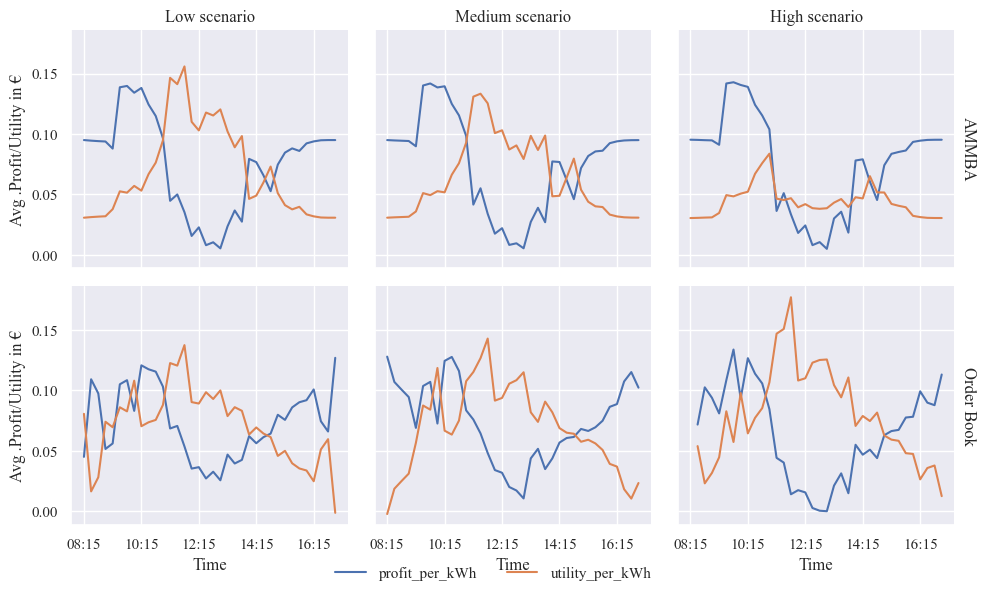

In [8]:
# calculate profit and demand
def calculate_profit_utiltiy(data):
    out = data.copy()
    out["k_upper"]=out.groupby("time")["buy_price"].transform("mean")
    out["k_lower"]=out.groupby("time")["sell_price"].transform("mean")
    sellers = out["surplus"]>0
    buyers = out["demand"]>0
    out.loc[sellers,"sold_energy"] = out[sellers]["energy_in"] - out[sellers]["energy_out"]
    out.loc[sellers,"profit"] = out[sellers].apply(lambda x: ((x["price"]-x["k_lower"])*x["sold_energy"]),axis=1)
    out.loc[buyers,"utility"] = out[buyers].apply(lambda x: ((x["k_upper"] - x["price"])*min(x["demand"],x["energy_out"]) - max(0,x["energy_out"]-x["demand"])*(x["price"] - x["k_lower"])),axis=1)
    out.loc[sellers,"profit_per_energy"] = out[sellers].apply(lambda x: (x["profit"]/x["energy_in"] if x["energy_in"]>0 else None),axis=1)
    out.loc[buyers,"utility_per_energy"] = out[buyers].apply(lambda x: (x["utility"]/x["energy_out"] if x["energy_out"]>0.0000000001 else None),axis=1)
    return out

data30 = calculate_profit_utiltiy(data30)
data30["scenario"]="Low"
data30["method"]="AMMBA"
data50 = calculate_profit_utiltiy(data50)
data50["scenario"]="Medium"
data50["method"]="AMMBA"
data70 = calculate_profit_utiltiy(data70)
data70["scenario"]="High"
data70["method"]="AMMBA"
data30_OMB = calculate_profit_utiltiy(data30_OMB)
data30_OMB["scenario"]="Low"
data30_OMB["method"]="Order Book"
data50_OMB = calculate_profit_utiltiy(data50_OMB)
data50_OMB["scenario"]="Medium"
data50_OMB["method"]="Order Book"
data70_OMB = calculate_profit_utiltiy(data70_OMB)
data70_OMB["scenario"]="High"
data70_OMB["method"]="Order Book"

data_long = pd.concat([data30,data50,data70,data30_OMB,data50_OMB,data70_OMB],ignore_index=True)
data_long_agg = data_long.groupby(["time","scenario","method"]).agg({"profit":"sum","utility":"sum","sold_energy":"sum","surplus":"sum","demand":"sum"}).reset_index()
data_long_agg["utility_per_kWh"]=data_long_agg["utility"]/data_long_agg["sold_energy"]
data_long_agg["profit_per_kWh"]=data_long_agg["profit"]/data_long_agg["sold_energy"]
data_long_agg["max_self_cons"]=data_long_agg.apply(lambda x: min(x["demand"],x["surplus"]),axis=1)
data_long_agg["utilized_energy"]=data_long_agg.apply(lambda x: min(x["sold_energy"],x["demand"]),axis=1)
data_long_agg["CSC"]=data_long_agg.apply(lambda x: min(x["sold_energy"],x["demand"])/x["surplus"],axis=1)
mlt1 = data_long_agg.melt(id_vars=["time","scenario","method"],value_vars=["profit_per_kWh","utility_per_kWh"],var_name="metric",value_name="value")

g = sns.FacetGrid(mlt1, col="scenario",row="method", margin_titles=True,col_order=["Low","Medium","High"],row_order=["AMMBA","Order Book"])
g.set_titles(col_template="{col_name} scenario", row_template="{row_name}")
g.map_dataframe(sns.lineplot, x="time", y="value",hue="metric",estimator="mean")
g.add_legend(loc="lower center",ncols=2)
ax = plt.gca()
ax.set_xticks(np.arange(0, len(prices_high), 8))
g.figure.set_size_inches(10,6)
g.set_axis_labels("Time","Avg .Profit/Utility in €")

plt.tight_layout()
plt.show()

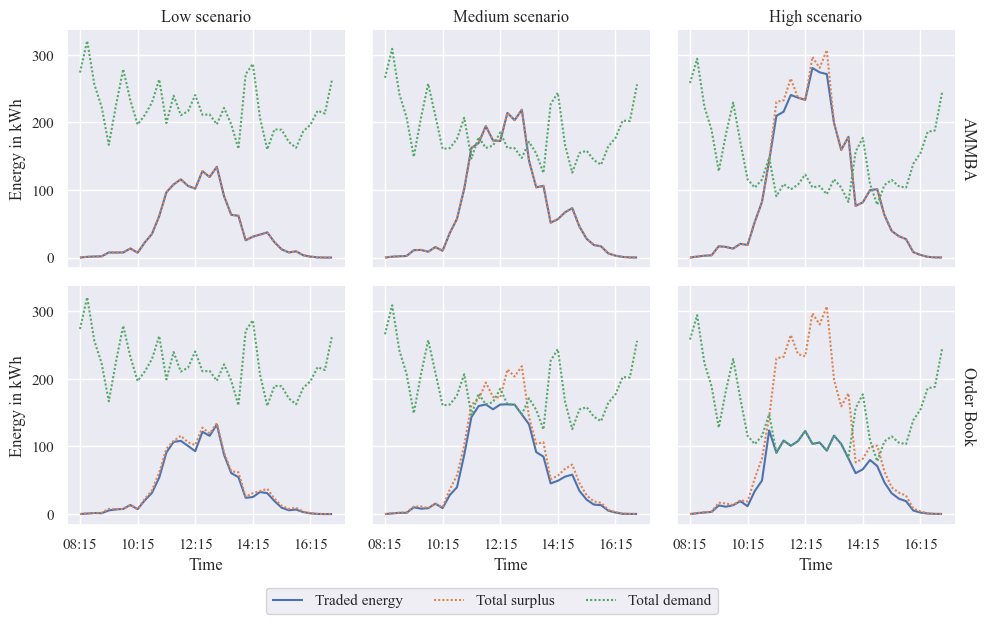

In [9]:
mlt2 = data_long_agg.melt(id_vars=["time","scenario","method"],value_vars=["sold_energy","surplus","demand"],var_name="metric",value_name="value")
g = sns.FacetGrid(mlt2, col="scenario",row="method", margin_titles=True,col_order=["Low","Medium","High"],row_order=["AMMBA","Order Book"])
g.set_titles(col_template="{col_name} scenario", row_template="{row_name}")
g.map_dataframe(sns.lineplot, x="time", y="value",hue="metric",estimator="mean",style="metric",dashes=[(1,0),(1, 1),(1,1)],fillstyle="full")
g.add_legend(legend_data={key: value for key, value in zip(["Traded energy","Total surplus","Total demand"], g._legend_data.values())},loc="lower center",ncols=3,bbox_to_anchor=(0.5, -0.05),frameon=True)
ax = plt.gca()
ax.set_xticks(np.arange(0, len(prices_high), 8))
g.figure.set_size_inches(10,6)
g.set_axis_labels("Time","Energy in kWh")
plt.tight_layout()
plt.show()
#g.figure.savefig("./Images/Sold_energy.png",bbox_inches='tight')

In [14]:
data_long["buy_price"]=data_long.groupby("time")["buy_price"].transform("mean")
data_long["value_ref"]= data_long.apply(lambda x: x["surplus"]*x["sell_price"] if x["surplus"]>0 else 0,axis=1)
data_long["value_mechanism"] = data_long.apply(lambda x: x["money_out"]-x["money_in"] + (x["surplus"] - x["sold_energy"])*x["sell_price"] if x["surplus"]>0 else
                                                min(x["energy_out"],x["demand"])*(x["buy_price"]-x["price"]) - max(x["energy_out"]-x["demand"],0)*(x["price"]-x["sell_price"]),axis=1)
data_long["profit_utility"]= data_long.apply(lambda x: x["profit"] if x["surplus"]>0 else x["utility"],axis=1)
data_long["has_value"] = data_long["value_mechanism"]>1e-5

In [23]:
data_long_agg_time = data_long.groupby(["scenario","method","time"]).agg({"profit":"sum","utility":"sum","sold_energy":"sum","surplus":"sum","demand":"sum","value_ref":"sum","value_mechanism":"sum","buy_price":"mean","sell_price":"mean","has_value":"count"})
data_long_agg_id = data_long.groupby(["scenario","method","ID"]).agg({"has_value":"max"}).groupby(["scenario","method"]).agg({"has_value":"sum"})
data_long_agg_time["value_max"] = data_long_agg_time.apply(lambda x: min(x["demand"],x["surplus"])*x["buy_price"] + max(x["surplus"]-x["demand"],0)*x["sell_price"] if x["surplus"]>0 else 0,axis=1)
data_long_agg_time["utilized_energy"]=data_long_agg_time.apply(lambda x: min(x["sold_energy"],x["demand"]),axis=1)
stats = data_long_agg_time.groupby(["scenario","method"]).agg({"profit":"sum","utility":"sum","sold_energy":"sum","surplus":"sum","demand":"sum","value_ref":"sum","value_mechanism":"sum","value_max":"sum","utilized_energy":"sum","has_value":"sum"})
stats["VI"] = (stats["value_mechanism"]-stats["value_ref"])/(stats["value_max"]-stats["value_ref"])
stats["PI"]= stats.apply(lambda x: data_long_agg_id.loc[x.name,"has_value"],axis=1)/250

def gini(x):
    x=list(x)
    # Mean absolute difference
    mad = np.abs(np.subtract.outer(x, x)).mean()
    # Relative mean absolute difference
    rmad = mad/np.mean(x)
    # Gini coefficient
    g = 0.5 * rmad
    return g

def calculate_EI(index):
    scenario,method = index
    grp = data_long.groupby(["scenario","method","ID"]).agg({"profit_utility":"sum"})
    return 1 - gini(grp.xs((scenario,method))["profit_utility"])

stats["Equality Index"] = stats.apply(lambda x: calculate_EI(x.name),axis=1)
stats["Total Welfare"]=stats["profit"]+stats["utility"]
stats["CSC"] = stats["utilized_energy"]/stats["surplus"]
stats.T.to_excel("./simulation_results/summary_stats.xlsx",index=True)